In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import torch
import torch.nn as nn
from torch import optim
from src.data.dataset import get_dataloader
from src.model.model import NGnet
from src.model.train import Trainer
import matplotlib.pyplot as plt
from src.psd.psd import plot_psd_scatter
from src.statistic_of_errors import evaluate_psd
import numpy as np


In [46]:
#Данные
train_dataloader, test_dataloader, (X_val, y_val, amplitudes_val) = get_dataloader(number_of_samples = 20000, amp_range=(2, 15), length=200, noise_std = 1)
# %%
#Модель
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = NGnet()
model.to(device=device)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=model.parameters(), lr=1e-4)


In [48]:
#тренировка
train_method = Trainer(
        model=model,
        loss=loss,
        optimizer=optimizer,
        device=device,

        
    )
history_of_train = train_method.fit(
    test_dataloader=test_dataloader,
    train_dataloader=train_dataloader,
    num_epochs=5
    
)



Эпоха 1/5


100%|██████████| 250/250 [00:01<00:00, 209.11it/s]


torch.Size([64])


100%|██████████| 63/63 [00:00<00:00, 399.86it/s]


torch.Size([32])
TRAIN -> loss: 0.18288819298148154, f1: 0.9519245104158631
VALIDATION -> loss: 0.18024815323333893, f1: 0.9499927989630507, errors: 200
Эпоха 2/5


...

torch.Size([32])
TRAIN -> loss: 0.15634044113755227, f1: 0.9541179735978005
VALIDATION -> loss: 0.15843942016363144, f1: 0.9504950495049505, errors: 198
Эпоха 5/5


100%|██████████| 250/250 [00:01<00:00, 210.64it/s]


torch.Size([64])


100%|██████████| 63/63 [00:00<00:00, 349.13it/s]


torch.Size([32])
TRAIN -> loss: 0.1508896633386612, f1: 0.9542435476252706
VALIDATION -> loss: 0.15404623232427098, f1: 0.9509955773508558, errors: 196


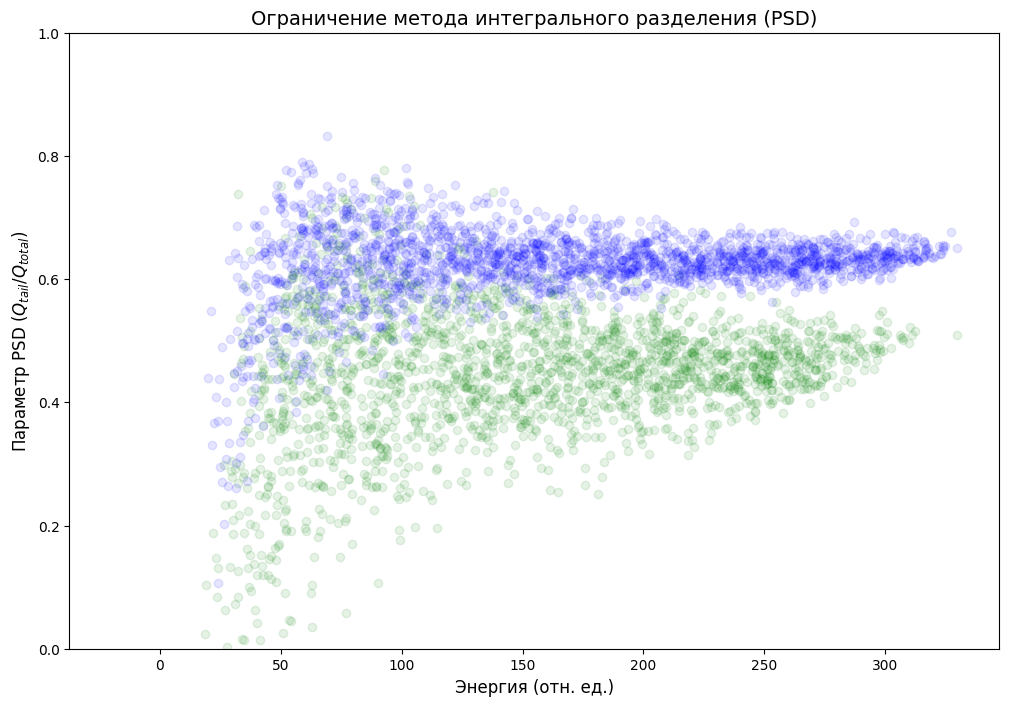

In [49]:

#Отрисовка
plot_psd_scatter(X=X_val, start_time=20, tail_time=30, y=y_val)
    

Количество ошибок PSD 380
Fuck380


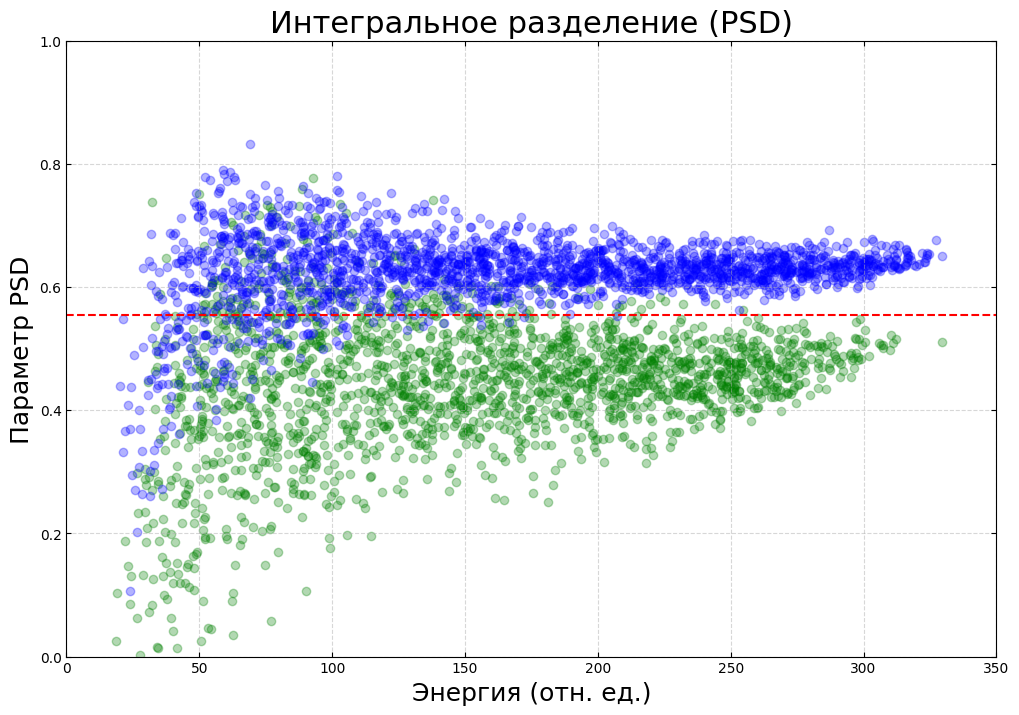

In [50]:
#PSD
min_errors, best_treshold = evaluate_psd(X_val, y_val)

Количество ошибок PSD 380
Fuck380


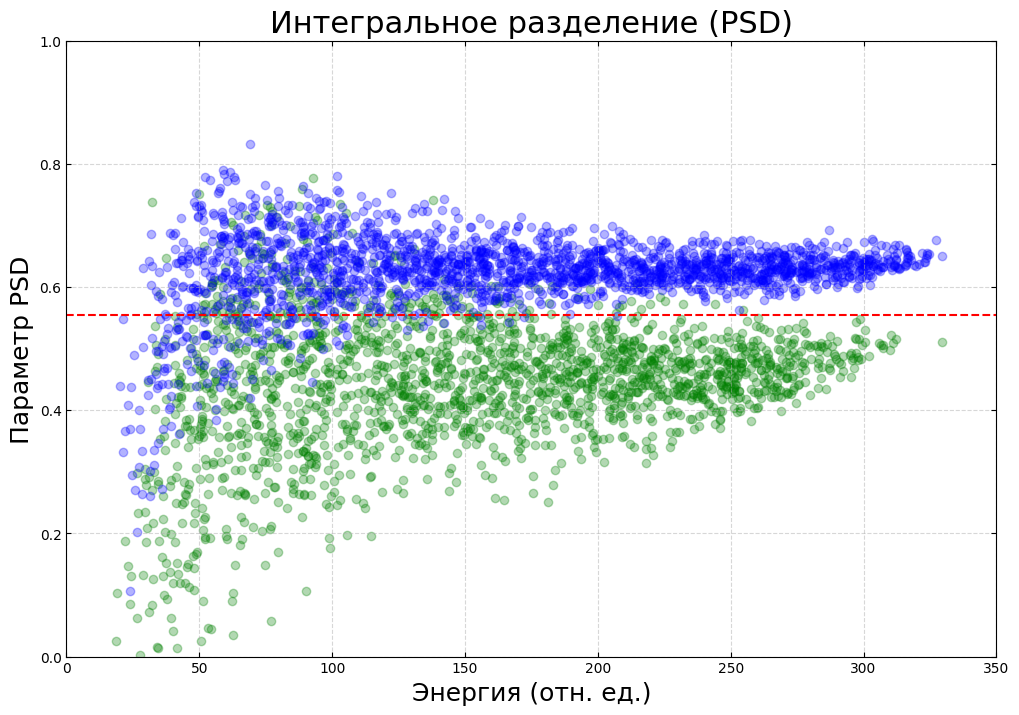

Ошибки 382


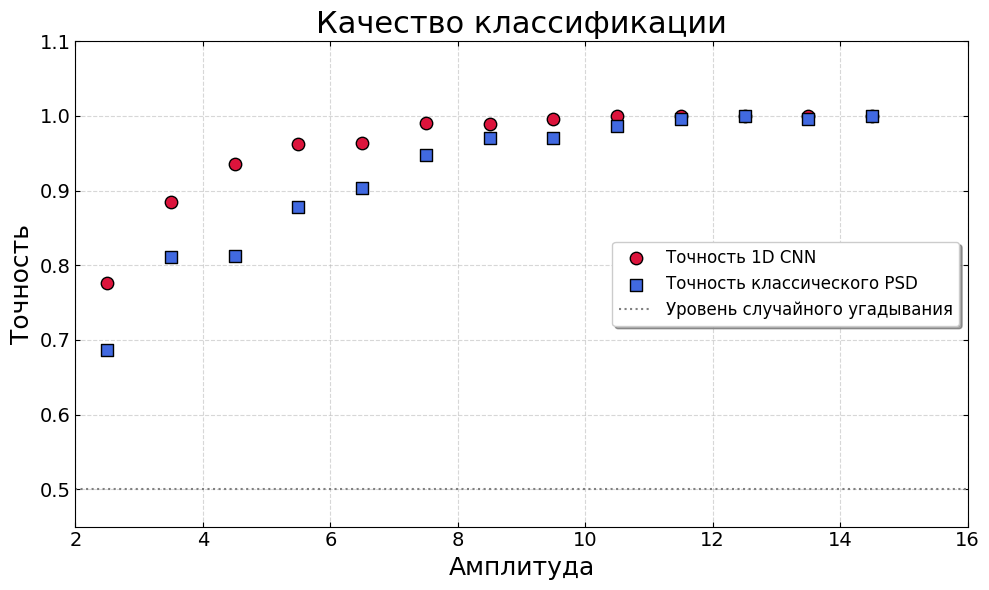

In [ ]:
model.eval()
with torch.no_grad():
    X_val_norm = X_val / np.max(X_val, axis=1, keepdims=True)
    X_test_tensor = torch.from_numpy(X_val_norm).float().to(device)
    logits = model(X_test_tensor).flatten()
    probs = torch.sigmoid(logits).cpu().numpy()

preds_cnn = (probs > 0.5).astype(int)
correct_cnn = (preds_cnn == y_val)

# 4. Расчет эффективности PSD для сравнения
from src.psd.psd import calculate_psd
from src.statistic_of_errors import evaluate_psd
_, psd_values = calculate_psd(X_val, start_time=20, tail_time=30)
_, best_t = evaluate_psd(X_val, y_val) # находим лучший порог
best_t = 0.57
preds_psd = (psd_values < best_t).astype(int)
correct_psd = (preds_psd == y_val)
print(f"Ошибки {4000 - np.sum(correct_psd)}")
# 5. Построение графика Efficiency vs Amplitude
bin_width = 1.0
bins = np.arange(2, 16, bin_width)
cnn_accs, psd_accs, centers = [], [], []

for b in bins[:-1]:
    mask = (amplitudes_val >= b) & (amplitudes_val < b + bin_width)
    if np.sum(mask) > 5:
        centers.append(b + bin_width/2)
        cnn_accs.append(np.mean(correct_cnn[mask]))
        psd_accs.append(np.mean(correct_psd[mask]))

from scipy.interpolate import make_interp_spline

plt.figure(figsize=(10, 6))

# Функция для генерации плавных линий
def get_smooth_curve(x, y):
    x_new = np.linspace(min(x), max(x), 300)
    spl = make_interp_spline(x, y, k=3) # k=3 - кубический сплайн
    return x_new, spl(x_new)

# 1. Сглаженные линии (рисуем их первыми, чтобы они были под точками)
"""x_smooth, y_cnn_smooth = get_smooth_curve(centers, cnn_accs)
plt.plot(x_smooth, y_cnn_smooth, color='crimson', alpha=0.3, linewidth=2, linestyle='--')

x_smooth, y_psd_smooth = get_smooth_curve(centers, psd_accs)
plt.plot(x_smooth, y_psd_smooth, color='royalblue', alpha=0.3, linewidth=2, linestyle='--')
"""
# 2. Точки (scatter) - они основные акценты
plt.scatter(centers, cnn_accs, color='crimson', label='Точность 1D CNN', s=80, edgecolors='black', zorder=5)
plt.scatter(centers, psd_accs, color='royalblue', marker='s', label='Точность классического PSD', s=80, edgecolors='black', zorder=5)

# 3. Оформление
plt.axhline(y=0.5, color='gray', linestyle=':', label='Уровень случайного угадывания')
plt.title('Качество классификации', fontsize=22)
plt.xlabel('Амплитуда', fontsize=18)
plt.ylabel('Точность', fontsize=18)

# Сетка и риски внутрь
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)

# Легенда и лимиты
plt.ylim(0.45, 1.1)
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.xlim(2, 16)

plt.tight_layout()
plt.show()

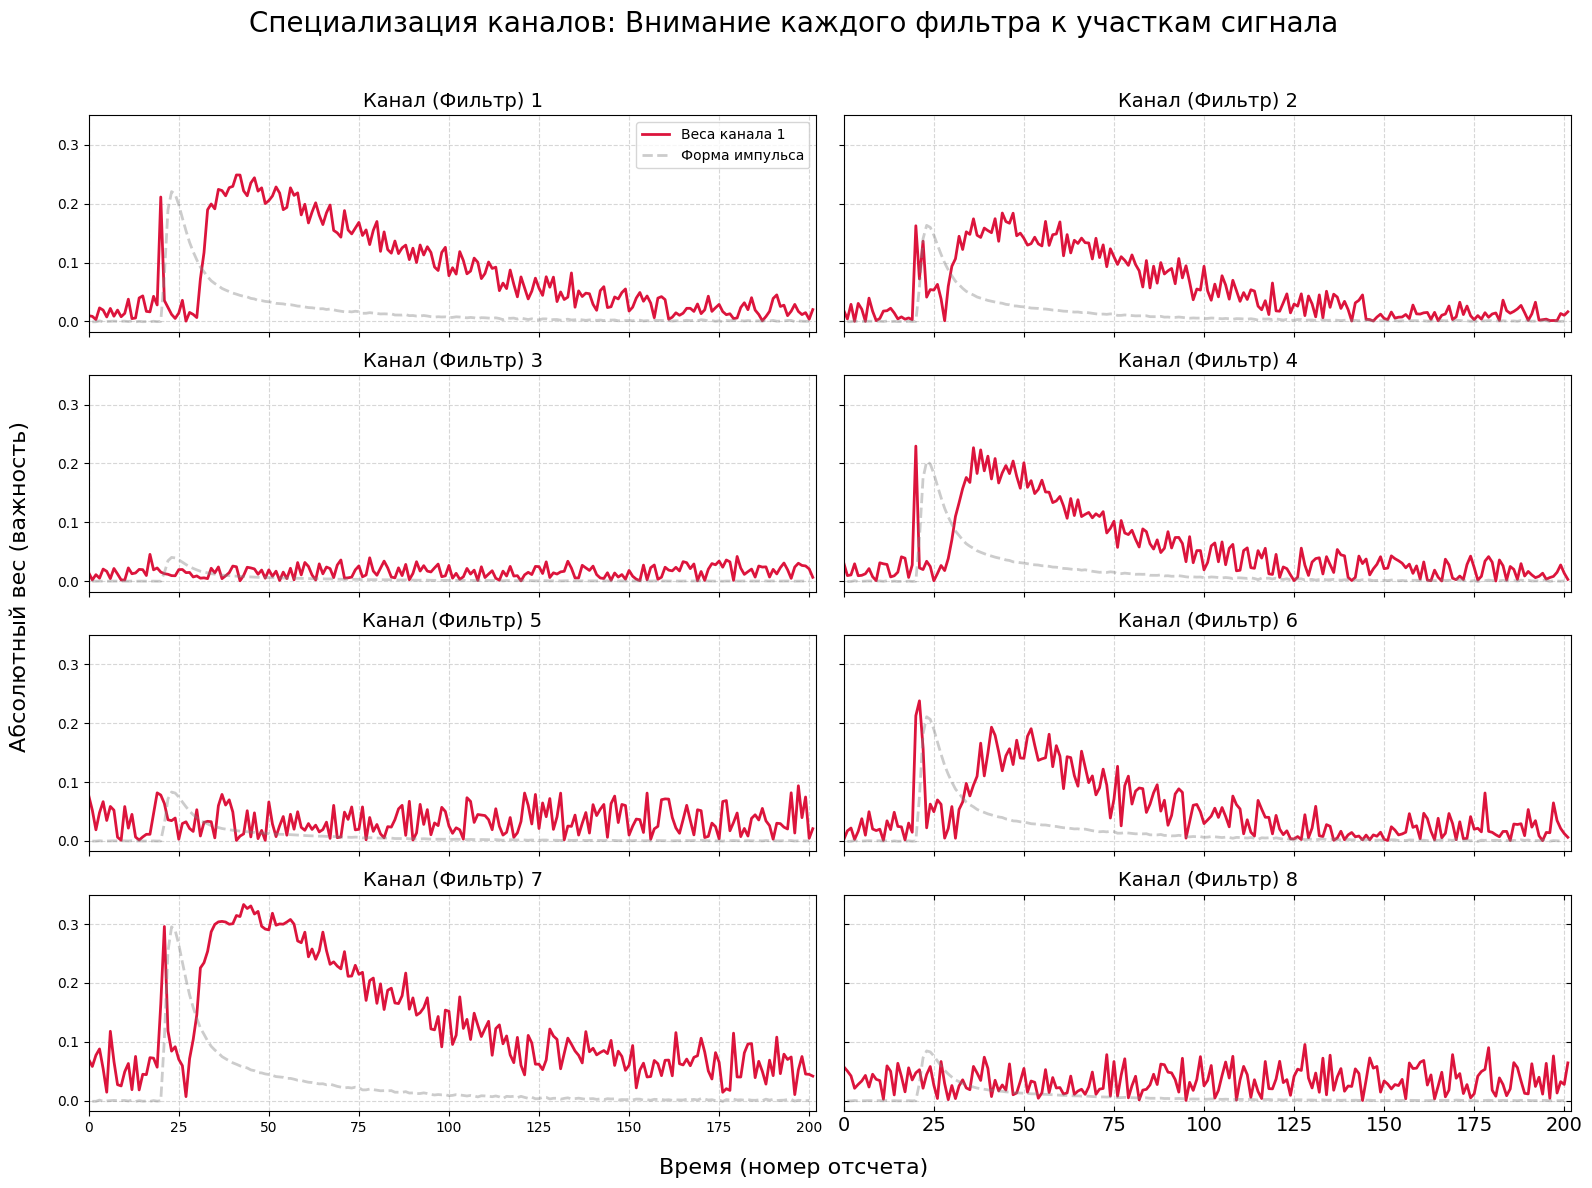

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Извлекаем веса полносвязного слоя
fc_weights = model.fc[0].weight.data.cpu().numpy() 

# Меняем форму весов обратно к виду: 8 каналов по 202 временных отсчета
weights_reshaped = fc_weights.reshape(8, -1) # -1 автоматически подставит 202

# Берем модуль весов
abs_weights = np.abs(weights_reshaped)

# Усредненный импульс для фона
mean_pulse = np.mean(X_val_norm, axis=0).flatten()
x_pulse = np.arange(1, len(mean_pulse) + 1)

# === Отрисовка графиков каждого канала ===
# Создаем сетку графиков 4x2
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten() # Вытягиваем массив осей в линию для удобного цикла

for i in range(8):
    ax = axes[i]
    
    # Рисуем веса текущего канала
    ax.plot(abs_weights[i], color='crimson', linewidth=2, label=f'Веса канала {i+1}')
    
    # Рисуем фоновый импульс (масштабируем его под веса для наглядности)
    # Умножаем на максимум весов в этом канале, чтобы импульс был фоном на той же высоте
    scale_factor = np.max(abs_weights[i]) if np.max(abs_weights[i]) > 0 else 1
    ax.plot(x_pulse, mean_pulse * scale_factor, color='gray', alpha=0.4, linestyle='--', linewidth=2, label='Форма импульса')
    
    # Оформление каждого маленького графика
    ax.set_title(f'Канал (Фильтр) {i+1}', fontsize=14)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=10)
    ax.set_xlim(0, 202)
    
    # Легенду добавляем только на первый график, чтобы не перегружать картинку
    if i == 0:
        ax.legend(loc='upper right')

# Общие подписи осей для всей фигуры
fig.text(0.5, 0.01, 'Время (номер отсчета)', ha='center', fontsize=16)
fig.text(0.01, 0.5, 'Абсолютный вес (важность)', va='center', rotation='vertical', fontsize=16)

plt.suptitle('Специализация каналов: Внимание каждого фильтра к участкам сигнала', fontsize=20, y=0.98)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.96]) # Оставляем место для общих подписей
plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)
plt.show()

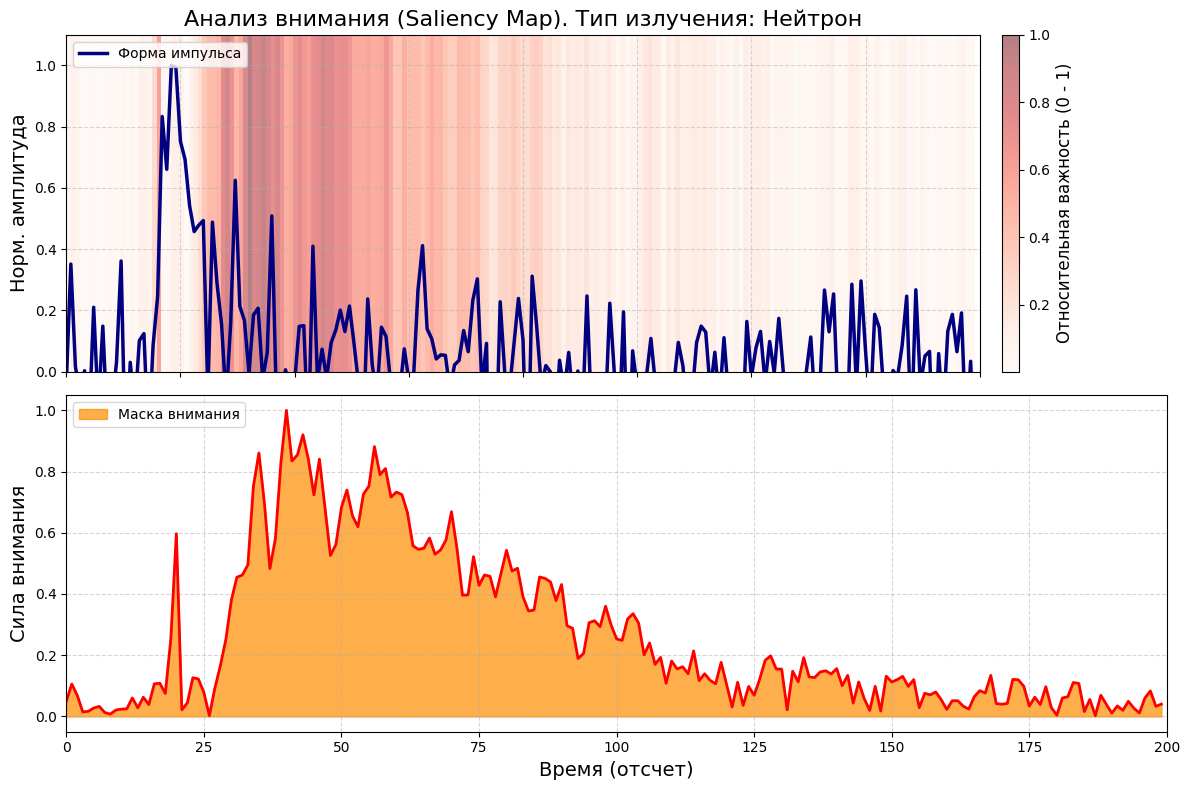

In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ВЫБИРАЕМ ИМПУЛЬС ДЛЯ АНАЛИЗА 
pulse_index = 0  
sample_pulse = X_val_norm[pulse_index]
true_class = y_val[pulse_index]
particle_name = "Нейтрон" if true_class == 1 else "Гамма-квант"

model.eval()

input_tensor = torch.from_numpy(sample_pulse).float().view(1, -1).to(device)
input_tensor.requires_grad_()
logit = model(input_tensor)
model.zero_grad()

logit.backward()
saliency_mask = input_tensor.grad.data.abs().squeeze().cpu().numpy()
saliency_mask = saliency_mask / np.max(saliency_mask)

x_time = np.arange(len(sample_pulse))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(x_time, sample_pulse, color='navy', linewidth=2.5, label='Форма импульса')
ax1.set_title(f'Анализ внимания (Saliency Map). Тип излучения: {particle_name}', fontsize=16)
ax1.set_ylabel('Норм. амплитуда', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

extent = [x_time[0], x_time[-1], 0, np.max(sample_pulse) * 1.1]
im = ax1.imshow(saliency_mask[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.5, extent=extent)

cbar = fig.colorbar(im, ax=ax1, orientation='vertical', pad=0.02)
cbar.set_label('Относительная важность (0 - 1)', fontsize=12)

ax2.fill_between(x_time, 0, saliency_mask, color='darkorange', alpha=0.7, label='Маска внимания')
ax2.plot(x_time, saliency_mask, color='red', linewidth=2)
ax2.set_ylabel('Сила внимания', fontsize=14)
ax2.set_xlabel('Время (отсчет)', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

plt.xlim(0, len(sample_pulse))
plt.tight_layout()
plt.show()

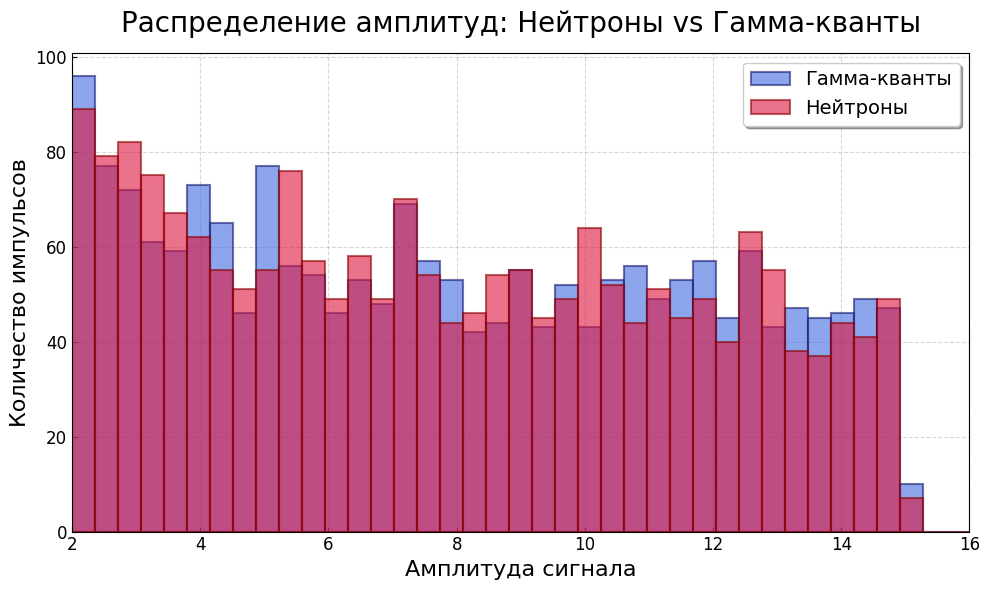

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Разделяем амплитуды по классам (0 - гамма, 1 - нейтроны)
amp_gamma = amplitudes_val[y_val == 0]
amp_neutron = amplitudes_val[y_val == 1]

# 2. Настройка фигуры
plt.figure(figsize=(10, 6), facecolor='white')

# Определяем общие границы корзин (bins) для честного сравнения
# Диапазон амплитуд у нас от 2 до 15, сделаем 40 корзин
bins = np.linspace(2, 16, 40)

# 3. Отрисовка гистограмм
# Гамма-кванты (синие)
plt.hist(amp_gamma, bins=bins, color='royalblue', alpha=0.6, 
         label='Гамма-кванты', edgecolor='midnightblue', linewidth=1.5, zorder=2)

# Нейтроны (красные)
plt.hist(amp_neutron, bins=bins, color='crimson', alpha=0.6, 
         label='Нейтроны', edgecolor='darkred', linewidth=1.5, zorder=2)

# 4. Оформление графика
plt.title('Распределение амплитуд: Нейтроны vs Гамма-кванты', fontsize=20, pad=15)
plt.xlabel('Амплитуда сигнала', fontsize=16)
plt.ylabel('Количество импульсов', fontsize=16)

# Сетка (zorder=0, чтобы она была позади гистограмм)
plt.grid(True, which='major', linestyle='--', alpha=0.5, zorder=0)

# Настройка осей
plt.tick_params(axis='both', which='major', labelsize=12, direction='in')
plt.xlim(2, 16)

# Легенда
plt.legend(fontsize=14, frameon=True, shadow=True, loc='upper right')

# Убираем лишние поля
plt.tight_layout()

# Вывод графика
plt.show()

In [61]:
len(amp_gamma)

2000

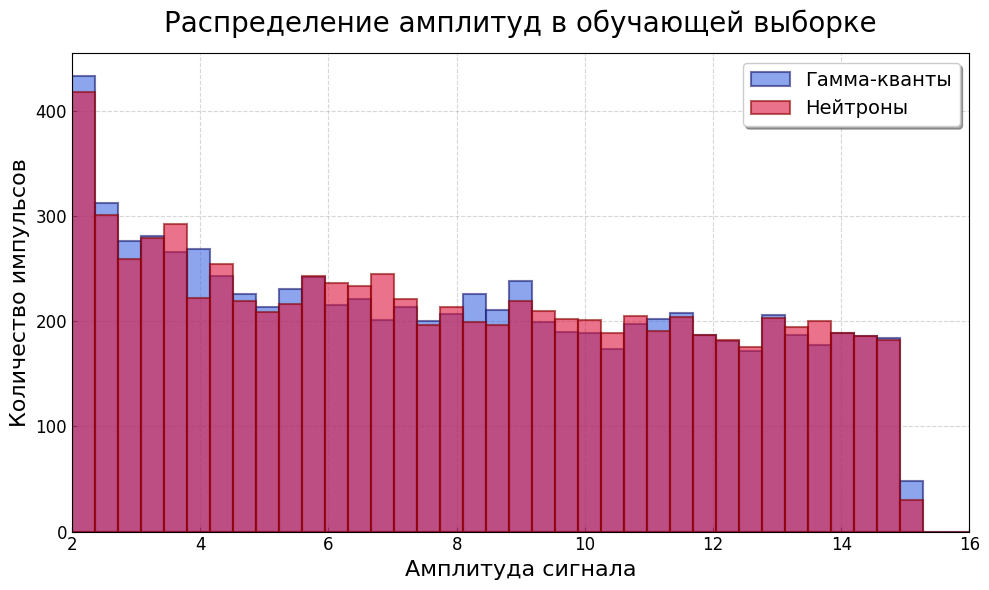

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import torch

all_train_amps = []
all_train_labels = []

# 1. Извлекаем данные батч за батчем из train_dataloader
for batch in train_dataloader:
    # Если твой Dataloader выдает 3 элемента (сигнал, метка, амплитуда)
    if len(batch) == 3:
        X_b, y_b, amp_b = batch
        all_train_amps.append(amp_b.cpu().numpy())
        all_train_labels.append(y_b.cpu().numpy())
    # Если Dataloader выдает 2 элемента (сигнал, метка)
    elif len(batch) == 2:
        X_b, y_b = batch
        # Если амплитуд нет в явном виде, вычисляем их как максимум в импульсе
        amp_b = torch.max(X_b, dim=-1)[0]
        all_train_amps.append(amp_b.cpu().numpy())
        all_train_labels.append(y_b.cpu().numpy())

# Объединяем списки батчей в один сплошной массив
train_amplitudes = np.concatenate(all_train_amps)
train_labels = np.concatenate(all_train_labels)

# 2. Разделяем амплитуды по классам (0 - гамма, 1 - нейтроны)
amp_gamma_train = train_amplitudes[train_labels == 0]
amp_neutron_train = train_amplitudes[train_labels == 1]

# 3. Настройка и отрисовка графика
plt.figure(figsize=(10, 6), facecolor='white')

# Границы корзин (bins)
bins = np.linspace(2, 16, 40)

# Гамма-кванты (синие)
plt.hist(amp_gamma_train, bins=bins, color='royalblue', alpha=0.6, 
         label='Гамма-кванты', edgecolor='midnightblue', linewidth=1.5, zorder=2)

# Нейтроны (красные)
plt.hist(amp_neutron_train, bins=bins, color='crimson', alpha=0.6, 
         label='Нейтроны', edgecolor='darkred', linewidth=1.5, zorder=2)

# Оформление
plt.title('Распределение амплитуд в обучающей выборке', fontsize=20, pad=15)
plt.xlabel('Амплитуда сигнала', fontsize=16)
plt.ylabel('Количество импульсов', fontsize=16)

# Сетка и оси
plt.grid(True, which='major', linestyle='--', alpha=0.5, zorder=0)
plt.tick_params(axis='both', which='major', labelsize=12, direction='in')
plt.xlim(2, 16)

# Легенда
plt.legend(fontsize=14, frameon=True, shadow=True, loc='upper right')

plt.tight_layout()
plt.show()

In [63]:
len(amp_gamma_train)

8000